In [50]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [51]:
G1 = np.array([[0, 0, 1, 0],
               [1, 0, 1, 0],
               [0, 0, 0, 1],
               [1, 1, 0, 0]])

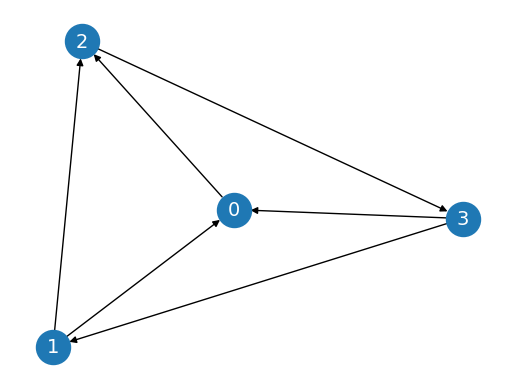

In [52]:
DiG1 = nx.from_numpy_array(G1, create_using = nx.DiGraph)
plt.axis('off')
nx.draw_networkx(DiG1,
                 pos = nx.spring_layout(DiG1, seed =0),
                 node_size = 600,
                 cmap = 'coolwarm',
                 font_size = 14,
                 font_color = 'white')

In [53]:
pagerankDiG1 = nx.pagerank(DiG1, alpha = 0.85)
pagerankDiG1

{0: 0.23343473174786417,
 1: 0.163813582448939,
 2: 0.30554155829031626,
 3: 0.2972101275128807}

In [54]:
N = len(DiG1.nodes)
damping_factor = 0.85
threshold = 1e-2
max_iter = 100
#Initial
PR = np.ones(N)/N
M = nx.to_numpy_array(DiG1, dtype = float).T
M/=M.sum(axis =0, where=M.sum(axis=0) !=0)

In [55]:
for i in range(max_iter):
  old_PR = PR.copy()
  PR = (1-damping_factor)/N + damping_factor *M @ PR
  print(f"Iteration {i +1}: {PR}")
  if np.linalg.norm(PR-old_PR, ord=1) < threshold:
    print (f"Stop Iteration {i + 1}")
    break

Iteration 1: [0.25    0.14375 0.35625 0.25   ]
Iteration 2: [0.20484375 0.14375    0.31109375 0.3403125 ]
Iteration 3: [0.24322656 0.18213281 0.27271094 0.30192969]
Iteration 4: [0.24322656 0.16582012 0.32164902 0.2693043 ]
Iteration 5: [0.22242788 0.15195433 0.31471613 0.31090167]
Iteration 6: [0.2342138  0.16963321 0.29114428 0.30500871]
Iteration 7: [0.23922282 0.1671287  0.30867584 0.28497264]
Iteration 8: [0.22964307 0.15861337 0.31186909 0.29987447]
Iteration 9: [0.23235733 0.16494665 0.30010729 0.30258873]
Iteration 10: [0.23620253 0.16610021 0.30510606 0.2925912 ]
Iteration 11: [0.23244385 0.16185126 0.30886474 0.29684015]
Iteration 12: [0.23244385 0.16365706 0.30386406 0.30003503]
Iteration 13: [0.23456914 0.16501489 0.30463152 0.29578445]
Stop Iteration 13


In [56]:
G2 = np.array([[0, 1, 1, 1, 0, 0, 0, 0],
               [1, 0, 1, 0, 0, 0, 0, 0],
               [1, 1, 0, 1, 0, 0, 0, 0],
               [1, 0, 1, 0, 1, 0, 0, 0],
               [0, 0, 0, 1, 0, 1, 0, 0],
               [0, 0, 0, 0, 1, 0, 1, 1],
               [0, 0, 0, 0, 0, 1, 0, 1],
               [0, 0, 0, 0, 0, 1, 1, 0]])

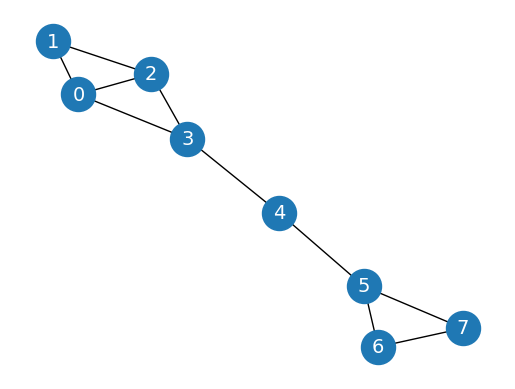

In [57]:
unDiG2 = nx.from_numpy_array(G2)
plt.axis('off')
nx.draw_networkx(unDiG2,
                 pos = nx.spring_layout(unDiG2, seed =0),
                 node_size = 600,
                 cmap = 'coolwarm',
                 font_size = 14,
                 font_color = 'white')

In [58]:
EigenVectorG2 = nx.eigenvector_centrality(unDiG2)
EigenVectorG2

{0: 0.5133681370460056,
 1: 0.38441577299424384,
 2: 0.5133681370460056,
 3: 0.47337089900084517,
 4: 0.2375887703642487,
 5: 0.16120160091894561,
 6: 0.09647910976519784,
 7: 0.09647910976519784}

Node 0 và 2 là egenvector

Hỏi chatgpt chỉnh mỗi step làm tròn 3 chữ số